# NYC Yellow Taxi Trip Analysis

> **Dataset:** NYC Yellow Taxi Trips in January 2019 (7.6M+ records)  
> **Goal:** Explore urban mobility patterns and build a machine learning model to predict tip amounts  
> **Tools:** Python · Pandas · Seaborn · GeoPandas · Scikit-Learn

## Table of Contents

| # | Section | Description |
|---|---------|-------------|
| 0 | [Setup](#0-setup) | Import libraries and configure the environment |
| 1 | [Data Engineering](#1-data-engineering) | Load, explore, clean and enrich the raw data |
| 2 | [Exploratory Analysis](#2-exploratory-data-analysis) | Answer business questions with charts |
| 3 | [Geospatial Analysis](#3-geospatial-analysis) | Visualise pickup hotspots across NYC zones |
| 4 | [Machine Learning](#4-machine-learning) | Train a model to predict tip amounts |
| 5 | [Conclusions](#5-conclusions) | Key findings and takeaways |

## 0. Setup

We begin by importing all the libraries we'll need throughout this notebook. Grouping them here keeps the rest of the notebook clean and makes dependency issues easy to spot at a glance.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# Plot styling
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False

print('All libraries loaded successfully.')

All libraries loaded successfully.


## 1. Data Engineering

Before we can draw any conclusions, we need to load the raw data, understand its structure, handle missing values, remove nonsensical records, and engineer a few helpful features. This section takes us from raw CSVs to a clean, analysis-ready DataFrame.

### 1.1 Load the Trip Data

The primary dataset is the TLC (Taxi & Limousine Commission) Yellow Taxi trip records for January 2019. Each row represents one completed trip.

In [2]:
# Load the main trip CSV
df = pd.read_csv('data/yellow_tripdata_2019-01.csv')

print(f'Trips loaded: {len(df):>12,}')
print(f'Columns: {df.shape[1]:>12}')
df.head()

Trips loaded:    7,667,792
Columns:           18


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge
0,1,2019-01-01 00:46:40,2019-01-01 00:53:20,1,1.5,1,N,151,239,1,7.0,0.5,0.5,1.65,0.0,0.3,9.95,NaN
1,1,2019-01-01 00:59:47,2019-01-01 01:18:59,1,2.6,1,N,239,246,1,14.0,0.5,0.5,1.00,0.0,0.3,16.30,NaN
2,2,2018-12-21 13:48:30,2018-12-21 13:52:40,3,0.0,1,N,236,236,1,4.5,0.5,0.5,0.00,0.0,0.3,5.80,NaN
3,2,2018-11-28 15:52:25,2018-11-28 15:55:45,5,0.0,1,N,193,193,2,3.5,0.5,0.5,0.00,0.0,0.3,7.55,NaN
4,2,2018-11-28 15:56:57,2018-11-28 15:58:33,5,0.0,2,N,193,193,2,52.0,0.0,0.5,0.00,0.0,0.3,55.55,NaN


### 1.2 Load the Zone Lookup Table

A second CSV maps every `LocationID` to a borough name and zone label. We'll use this later to add human-readable geography to the trip data.

In [3]:
# Map LocationID to Borough / Zone name
zones = pd.read_csv('data/taxi+_zone_lookup.csv')
zones.head()

,LocationID,Borough,Zone,service_zone
0,1,EWR,Newark Airport,EWR
1,2,Queens,Jamaica Bay,Boro Zone
2,3,Bronx,Allerton/Pelham Gardens,Boro Zone
3,4,Manhattan,Alphabet City,Yellow Zone
4,5,Staten Island,Arden Heights,Boro Zone


### 1.3 Explore the Raw Data

A quick sanity check: data types, summary statistics, and missing values. This helps us understand what cleaning is needed before we proceed.

In [4]:
# What columns do we have and types?
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7667792 entries, 0 to 7667791
Data columns (total 18 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   VendorID               int64  
 1   tpep_pickup_datetime   object 
 2   tpep_dropoff_datetime  object 
 3   passenger_count        int64  
 4   trip_distance          float64
 5   RatecodeID             int64  
 6   store_and_fwd_flag     object 
 7   PULocationID           int64  
 8   DOLocationID           int64  
 9   payment_type           int64  
 10  fare_amount            float64
 11  extra                  float64
 12  mta_tax                float64
 13  tip_amount             float64
 14  tolls_amount           float64
 15  improvement_surcharge  float64
 16  total_amount           float64
 17  congestion_surcharge   float64
dtypes: float64(9), int64(6), object(3)
memory usage: 1.0+ GB


In [5]:
# Basic statistics — min, max, average for each column
df.describe()

,VendorID,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge
count,7.667792e+06,7.667792e+06,7.667792e+06,7.667792e+06,7.667792e+06,7.667792e+06,7.667792e+06,7.667792e+06,7.667792e+06,7.667792e+06,7.667792e+06,7.667792e+06,7.667792e+06,7.667792e+06,2.811814e+06
mean,1.636775e+00,1.567078e+00,2.801084e+00,1.058371e+00,1.655009e+02,1.637529e+02,1.291776e+00,1.240941e+01,3.280394e-01,4.968458e-01,1.827367e+00,3.169187e-01,2.993382e-01,1.568222e+01,3.289691e-05
std,5.398204e-01,1.224431e+00,3.737529e+00,6.780889e-01,6.639180e+01,7.036445e+01,4.733229e-01,2.620721e+02,5.074789e-01,5.337843e-02,2.501213e+00,2.023665e+00,1.911711e-02,2.622932e+02,9.068695e-03
min,1.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,-3.620000e+02,-6.000000e+01,-5.000000e-01,-6.350000e+01,-7.000000e+01,-3.000000e-01,-3.628000e+02,0.000000e+00
25%,1.000000e+00,1.000000e+00,9.000000e-01,1.000000e+00,1.300000e+02,1.130000e+02,1.000000e+00,6.000000e+00,0.000000e+00,5.000000e-01,0.000000e+00,0.000000e+00,3.000000e-01,8.190000e+00,0.000000e+00
50%,2.000000e+00,1.000000e+00,1.530000e+00,1.000000e+00,1.620000e+02,1.620000e+02,1.000000e+00,8.500000e+00,0.000000e+00,5.000000e-01,1.430000e+00,0.000000e+00,3.000000e-01,1.127000e+01,0.000000e+00
75%,2.000000e+00,2.000000e+00,2.800000e+00,1.000000e+00,2.340000e+02,2.340000e+02,2.000000e+00,1.350000e+01,5.000000e-01,5.000000e-01,2.330000e+00,0.000000e+00,3.000000e-01,1.656000e+01,0.000000e+00
max,4.000000e+00,9.000000e+00,8.318000e+02,9.900000e+01,2.650000e+02,2.650000e+02,4.000000e+00,6.232599e+05,5.353800e+02,6.080000e+01,7.872500e+02,3.288000e+03,6.000000e-01,6.232617e+05,2.500000e+00


In [6]:
# How many missing values do we have?
missing = df.isnull().sum()
missing[missing > 0]

congestion_surcharge    4855978
dtype: int64

### 1.4 Feature Engineering

The raw datetime columns aren't directly useful for analysis. We extract the **hour**, **day of week**, and **trip duration** so they can be used as features in our model and as grouping variables in our charts.

In [7]:
# Parse datetime strings
df['tpep_pickup_datetime']  = pd.to_datetime(df['tpep_pickup_datetime'])
df['tpep_dropoff_datetime'] = pd.to_datetime(df['tpep_dropoff_datetime'])

# Derive useful time-based features
df['pickup_hour']       = df['tpep_pickup_datetime'].dt.hour
df['pickup_day']        = df['tpep_pickup_datetime'].dt.day_name()
df['trip_duration_min'] = (
    df['tpep_dropoff_datetime'] - df['tpep_pickup_datetime']
).dt.total_seconds() / 60

print('New features added: pickup_hour, pickup_day, trip_duration_min')

New features added: pickup_hour, pickup_day, trip_duration_min


### 1.5 Data Cleaning

The raw data contains physically impossible records: trips with zero distance, negative fares, zero passengers, or durations over three hours. These are almost certainly data-entry errors or system anomalies, so we remove them before analysis.

In [8]:
before = len(df)

df = df[
    (df['trip_distance']     >   0) &   # must travel some distance
    (df['fare_amount']       >   0) &   # fare can't be free or negative
    (df['passenger_count']   >   0) &   # at least one passenger
    (df['trip_duration_min'] >   0) &   # must take some time
    (df['trip_duration_min'] < 180)     # cap at 3 hours (likely data errors beyond this)
]

removed = before - len(df)
print(f'Rows removed: {removed:>12,}  ({removed/before:.1%} of original data)')
print(f'Rows kept: {len(df):>12,}')

Rows removed:      198,013  (2.6% of original data)
Rows kept:    7,469,779


### 1.6 Join with Zone Lookup

We enrich each trip with the **pickup borough name** by joining on `PULocationID`. This turns a numeric zone ID into something meaningful like *Manhattan* or *Queens*.

In [9]:
# Left-join to attach borough names
df = df.merge(
    zones[['LocationID', 'Borough']],
    left_on='PULocationID',
    right_on='LocationID',
    how='left'
).rename(columns={'Borough': 'pickup_borough'})

print('pickup_borough column added')
print(df['pickup_borough'].value_counts().to_string())

pickup_borough column added
pickup_borough
Manhattan        6783993
Queens            443480
Unknown           145499
Brooklyn           82171
Bronx              14221
Staten Island        286
EWR                  129


In [10]:
# Final look at the enriched dataset
df.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,...,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,pickup_hour,pickup_day,trip_duration_min,LocationID,pickup_borough
0,1,2019-01-01 00:46:40,2019-01-01 00:53:20,1,1.5,1,N,151,239,1,...,1.65,0.0,0.3,9.95,NaN,0,Tuesday,6.666667,151,Manhattan
1,1,2019-01-01 00:59:47,2019-01-01 01:18:59,1,2.6,1,N,239,246,1,...,1.00,0.0,0.3,16.30,NaN,0,Tuesday,19.200000,239,Manhattan
2,1,2019-01-01 00:21:28,2019-01-01 00:28:37,1,1.3,1,N,163,229,1,...,1.25,0.0,0.3,9.05,NaN,0,Tuesday,7.150000,163,Manhattan
3,1,2019-01-01 00:32:01,2019-01-01 00:45:39,1,3.7,1,N,229,7,1,...,3.70,0.0,0.3,18.50,NaN,0,Tuesday,13.633333,229,Manhattan
4,1,2019-01-01 00:57:32,2019-01-01 01:09:32,2,2.1,1,N,141,234,1,...,1.70,0.0,0.3,13.00,NaN,0,Tuesday,12.000000,141,Manhattan


## 2. Exploratory Data Analysis

Now that the data is clean, we ask five concrete business questions and answer each one with a chart. Good EDA is about letting the data tell a story, not just making pretty pictures.

### Q1: When are taxis busiest during the day?

Understanding **hourly demand** helps dispatch teams staff drivers efficiently and helps riders know when wait times will be short or long.

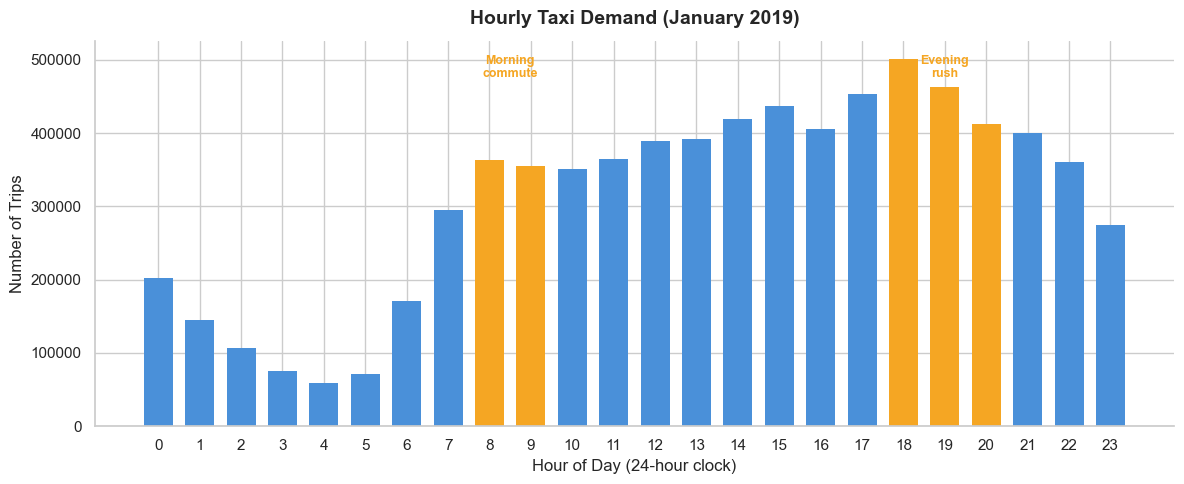

In [11]:
trips_by_hour = df.groupby('pickup_hour').size()

fig, ax = plt.subplots()

peak_hours = [8, 9, 18, 19, 20]
colors = ['#F5A623' if h in peak_hours else '#4A90D9' for h in trips_by_hour.index]

ax.bar(trips_by_hour.index, trips_by_hour.values, color=colors, width=0.7, edgecolor='none')

ax.set_title('Hourly Taxi Demand (January 2019)', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Hour of Day (24-hour clock)')
ax.set_ylabel('Number of Trips')
ax.set_xticks(range(0, 24))

# Annotate peak hours
ax.text(8.5, trips_by_hour.max() * 0.95, 'Morning\ncommute', ha='center', fontsize=9, color='#F5A623', fontweight='bold')
ax.text(19,  trips_by_hour.max() * 0.95, 'Evening\nrush',    ha='center', fontsize=9, color='#F5A623', fontweight='bold')

plt.tight_layout()
plt.savefig('images/hourly_demand.png', dpi=150, bbox_inches='tight')
plt.show()

### Q2: Which day of the week is the busiest?

Day-of-week patterns reveal whether taxi use is primarily **commuter-driven** (weekdays) or **leisure-driven** (weekends).

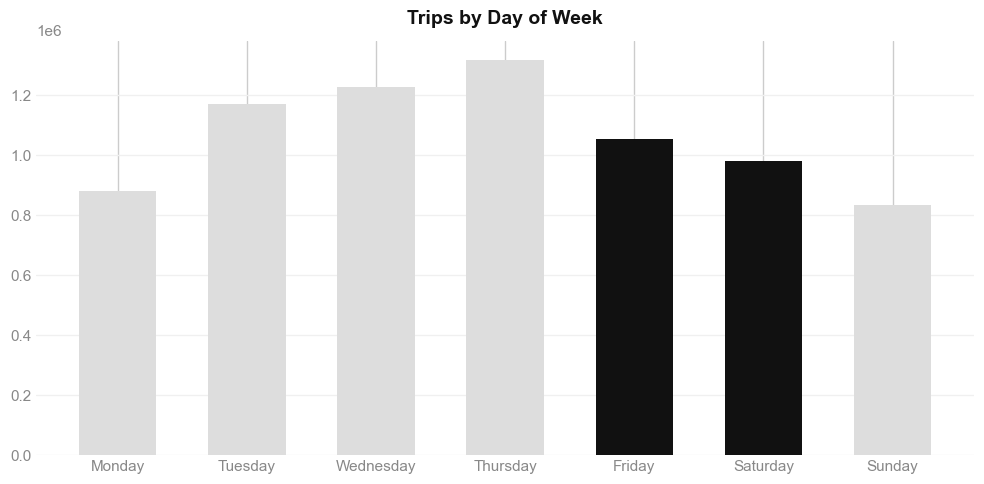

In [12]:
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
trips_by_day = df.groupby('pickup_day').size().reindex(day_order)

fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor('#ffffff')
ax.set_facecolor('#ffffff')

colors = ['#111111' if d in ['Friday','Saturday'] else '#dddddd' for d in day_order]
ax.bar(day_order, trips_by_day.values, color=colors, edgecolor='none', width=0.6)

ax.set_title('Trips by Day of Week', color='#111111', fontsize=14, fontweight='bold', pad=12)
ax.tick_params(colors='#888888', length=0)
ax.yaxis.grid(True, color='#f0f0f0')
ax.set_axisbelow(True)
for spine in ax.spines.values():
    spine.set_visible(False)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Q3: Which borough generates the most revenue?

Total revenue by pickup borough tells us where the most economically valuable trips originate. This is critical for fleet allocation decisions.

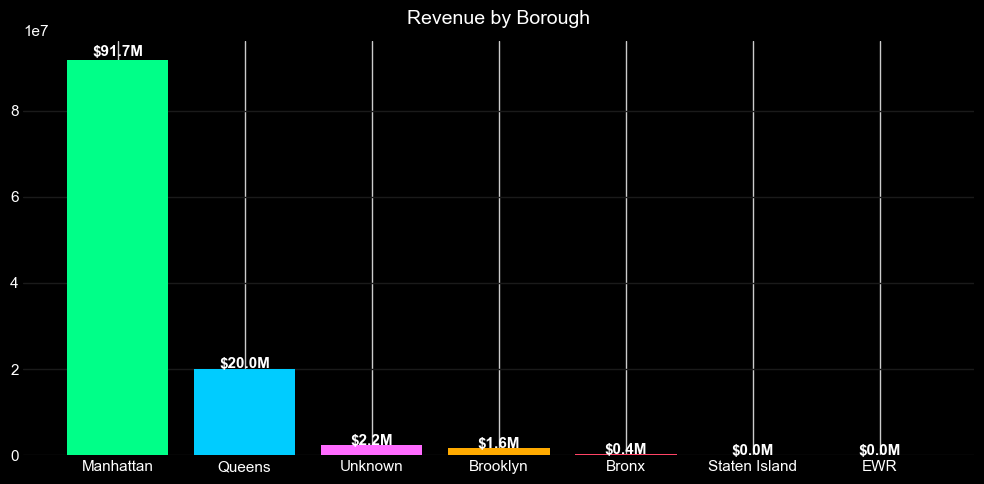

In [13]:
revenue_by_borough = df.groupby('pickup_borough')['total_amount'].sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor('#000000')
ax.set_facecolor('#000000')

bars = ax.bar(revenue_by_borough.index, revenue_by_borough.values,
              color=['#00ff88','#00ccff','#ff6bff','#ffaa00','#ff4466'], edgecolor='none')
for bar, val in zip(bars, revenue_by_borough.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height()*1.01,
            f"${val/1e6:.1f}M", ha='center', color='white', fontsize=11, fontweight='bold')

ax.set_title('Revenue by Borough', color='white', fontsize=14, pad=12)
ax.tick_params(colors='white', length=0)
ax.yaxis.grid(True, color='#1a1a1a')
ax.set_axisbelow(True)
for spine in ax.spines.values():
    spine.set_visible(False)
plt.tight_layout()
plt.savefig('images/revenue_by_borough.png', dpi=150, bbox_inches='tight')
plt.show()

### Q4: Do longer trips attract higher tips?

A scatter plot of trip distance vs. tip amount can reveal whether distance is a reliable predictor of tipping behaviour, or whether other factors dominate.

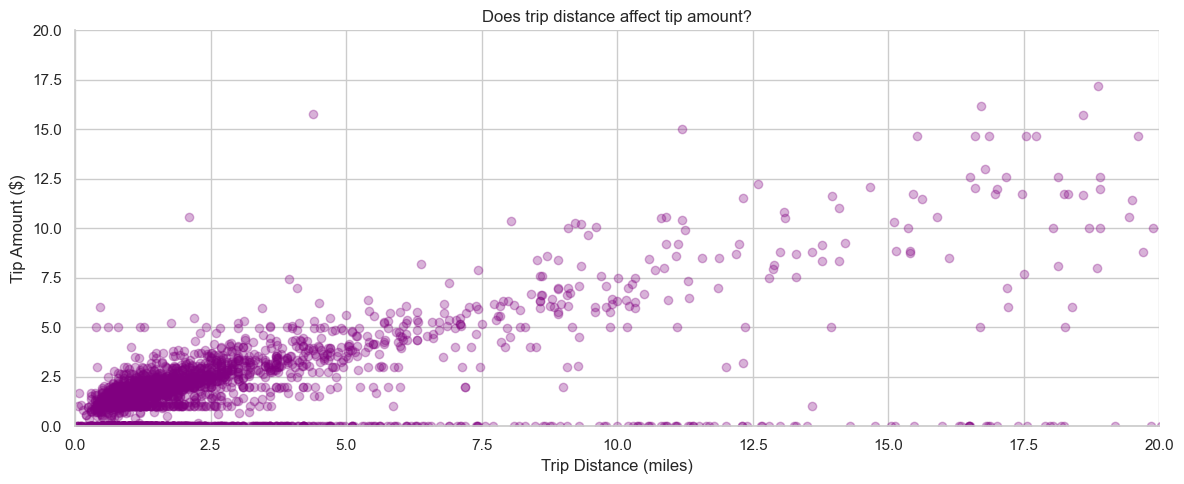

In [14]:
# Take a small random sample so the plot doesn't get too crowded
sample = df.sample(3000, random_state=42)

plt.figure()
plt.scatter(sample['trip_distance'], sample['tip_amount'], alpha=0.3, color='purple')
plt.title('Does trip distance affect tip amount?')
plt.xlabel('Trip Distance (miles)')
plt.ylabel('Tip Amount ($)')
plt.xlim(0, 20)
plt.ylim(0, 20)
plt.tight_layout()
plt.show()

### Q5: What does the fare amount distribution look like?

The fare distribution reveals the typical trip cost and highlights outliers. A right-skewed distribution is expected in a city where most trips are short hops across town.

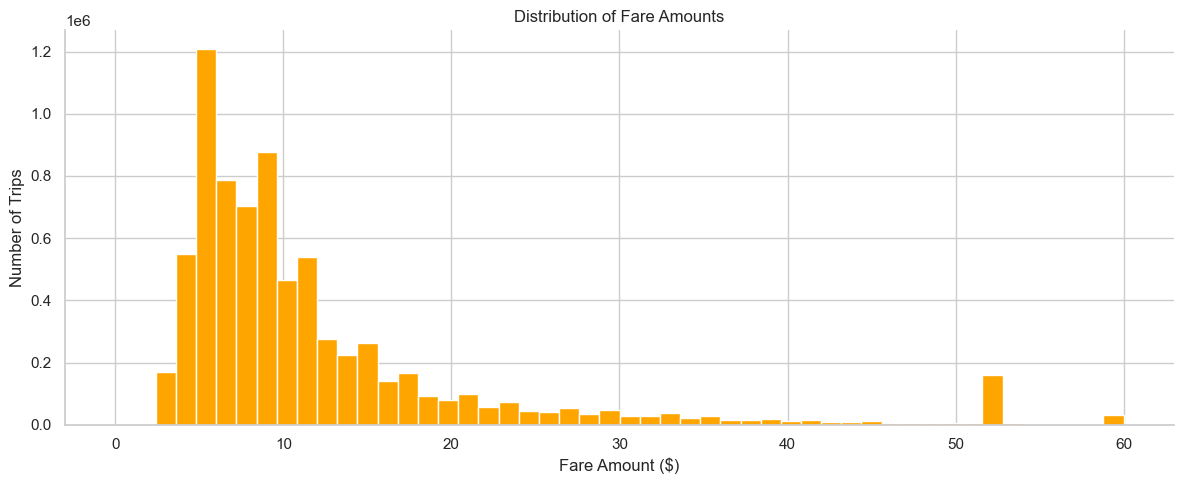

Average fare: $12.26
Median fare:  $9.00


In [15]:
plt.figure()
df['fare_amount'].clip(0, 60).hist(bins=50, color='orange', edgecolor='white')
plt.title('Distribution of Fare Amounts')
plt.xlabel('Fare Amount ($)')
plt.ylabel('Number of Trips')
plt.tight_layout()
plt.show()

print(f"Average fare: ${df['fare_amount'].mean():.2f}")
print(f"Median fare:  ${df['fare_amount'].median():.2f}")

## 3. Geospatial Analysis

By joining our trip data with NYC's official taxi zone shapefile, we can paint a choropleth map showing which zones see the heaviest pickup activity. 

Bright red = high demand

yellow = moderate

white = low

### 3.1: Load the Zone Shapefile

NYC publishes an official shapefile of all 263 taxi zones. GeoPandas reads it directly and gives us a GeoDataFrame with geometry column ready to plot.

In [16]:
# Load the shapefile
gdf = gpd.read_file('data/taxi_zones/taxi_zones.shp')

print(f'Number of zones: {len(gdf)}')
gdf.head()

Number of zones: 263


,OBJECTID,Shape_Leng,Shape_Area,zone,LocationID,borough,geometry
0,1,0.116357,0.000782,Newark Airport,1,EWR,"POLYGON ((933100.918 192536.086, 933091.011 19..."
1,2,0.433470,0.004866,Jamaica Bay,2,Queens,"MULTIPOLYGON (((1033269.244 172126.008, 103343..."
2,3,0.084341,0.000314,Allerton/Pelham Gardens,3,Bronx,"POLYGON ((1026308.77 256767.698, 1026495.593 2..."
3,4,0.043567,0.000112,Alphabet City,4,Manhattan,"POLYGON ((992073.467 203714.076, 992068.667 20..."
4,5,0.092146,0.000498,Arden Heights,5,Staten Island,"POLYGON ((935843.31 144283.336, 936046.565 144..."


### 3.2: Choropleth Map: Pickup Hotspots

We count the trips that originated in each zone and join those counts back to the GeoDataFrame, then colour each polygon by its trip volume.

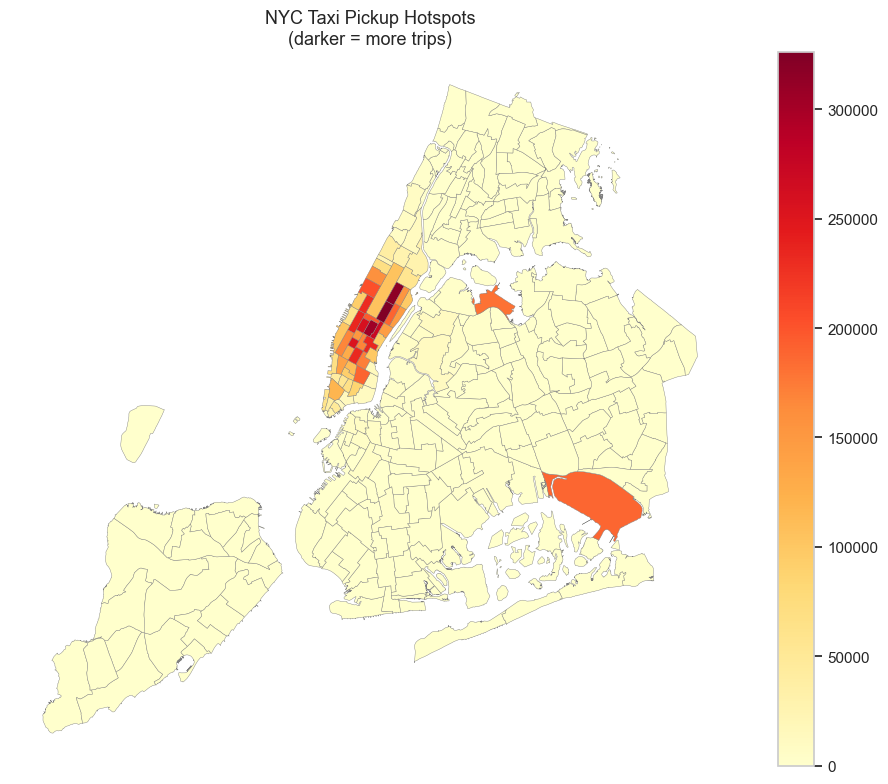

In [17]:
# Count how many trips started in each zone
trip_counts = df.groupby('PULocationID').size().reset_index(name='trips')

# Join trip counts to the map
gdf = gdf.merge(trip_counts, left_on='LocationID', right_on='PULocationID', how='left')
gdf['trips'] = gdf['trips'].fillna(0)

# Plot the map — darker = more trips
fig, ax = plt.subplots(figsize=(10, 8))
gdf.plot(column='trips', cmap='YlOrRd', linewidth=0.3,
         edgecolor='grey', legend=True, ax=ax)
ax.set_title('NYC Taxi Pickup Hotspots\n(darker = more trips)', fontsize=13)
ax.axis('off')
plt.tight_layout()
plt.savefig('images/nyc_heatmap.png', dpi=150, bbox_inches='tight')  
plt.show()

## 4. Machine Learning: Tip Amount Prediction

Can we predict how much a passenger will tip, given what we know about the trip *before* it ends? We frame this as a **regression problem**: the target variable is `tip_amount` and the inputs are features available at dropoff time.

We use a **Random Forest Regressor** an ensemble of decision trees that is robust to outliers, requires minimal preprocessing, and gives us feature importance scores for free.

### 4.1 Prepare Features & Target

We select the five features most logically related to tipping, drop any rows with null values in those columns, then split inputs (X) from target (y).

In [18]:
# Feature set — things we know about a trip at dropoff
features = ['trip_distance', 'fare_amount', 'pickup_hour', 'passenger_count', 'trip_duration_min']
target   = 'tip_amount'

ml_df = df[features + [target]].dropna()

X = ml_df[features]
y = ml_df[target]

print(f'Feature matrix shape : {X.shape}')
print(f'Target vector shape  : {y.shape}')
print(f'Features used        : {features}')

Feature matrix shape : (7469779, 5)
Target vector shape  : (7469779,)
Features used        : ['trip_distance', 'fare_amount', 'pickup_hour', 'passenger_count', 'trip_duration_min']


### 4.2 Train / Test Split

We hold out 20% of the data as a test set. The model will never see these records during training, so performance on them is an honest estimate of real-world accuracy.

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'Training rows: {len(X_train):>12,}')
print(f'Testing rows: {len(X_test):>12,}')

Training rows:    5,975,823
Testing rows:    1,493,956


### 4.3 Train the Random Forest Model

Training on 7M+ rows would take a long time on a laptop, so we randomly sample 100,000 training records: a common trick that gives us ~95% of the accuracy at ~1% of the compute time.

In [20]:
# Sub-sample training set for speed (100k rows is plenty to learn from)
sample_idx = X_train.sample(100_000, random_state=42).index

model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
model.fit(X_train.loc[sample_idx], y_train.loc[sample_idx])

print('Model trained successfully.')

Model trained successfully.


### 4.4 Evaluate the Model

We score the model on the held-out test set using two standard regression metrics:

- **MAE** (Mean Absolute Error)

average dollar-amount error per prediction

- **R²** (Coefficient of Determination)

what fraction of the variance in tips is explained by our features

In [21]:
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
r2  = r2_score(y_test, y_pred)

print(f'Mean Absolute Error (MAE): ${mae:.2f}')
print(f'R² Score:  {r2:.3f}')
print()
print('Interpretation:')
print(f'On average our tip prediction is off by ${mae:.2f}')
print(f'Our features explain {r2:.0%} of the variance in tip amounts')

Mean Absolute Error (MAE): $1.24
R² Score:  0.304

Interpretation:
On average our tip prediction is off by $1.24
Our features explain 30% of the variance in tip amounts


### 4.5 Feature Importance

Random Forests naturally measure how much each feature contributed to splitting decisions across all 100 trees. Higher importance = more predictive power.

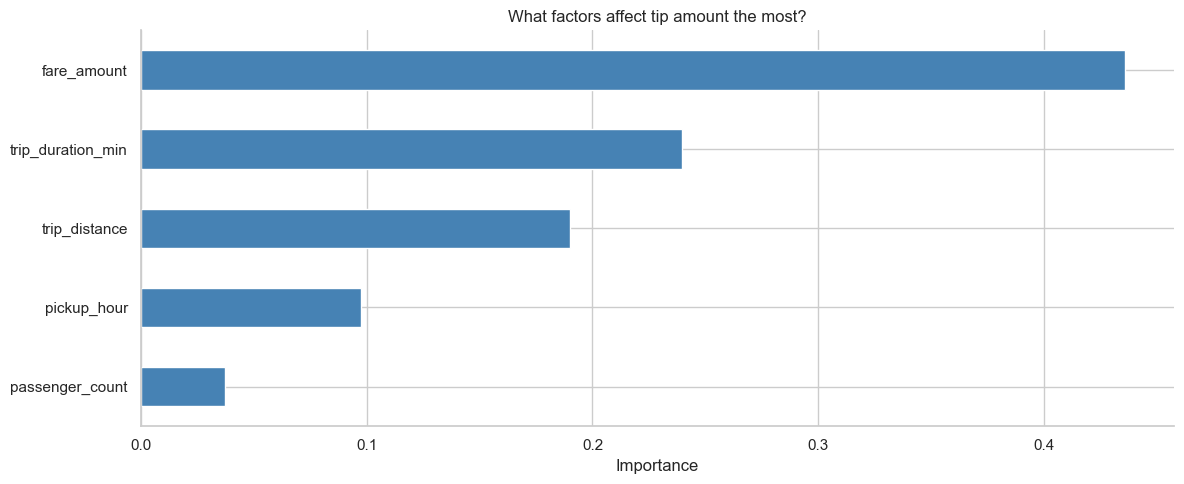

In [22]:
# Which features matter most for predicting tips?
importance = pd.Series(model.feature_importances_, index=features).sort_values()

importance.plot(kind='barh', color='steelblue')
plt.title('What factors affect tip amount the most?')
plt.xlabel('Importance')
plt.tight_layout()
plt.savefig('images/feature_importance.png', dpi=150, bbox_inches='tight')  # ← save BEFORE show
plt.show()

## 5. Conclusions

After cleaning and analysing 7.4 million NYC yellow taxi trips from January 2019, a clear picture of how this city moves emerges. Here is what we found: organised by theme, explained in plain terms.


### Demand Patterns

**Finding:** Taxi demand follows a classic double-peak pattern, with the busiest windows at **8–9 AM** (morning commute) and **6–8 PM** (evening rush). The quietest stretch is 2–5 AM, though trips never fully stop.

**What this means:** New York's taxi demand is tightly tied to the working day. The city wakes up, floods the streets, pauses, and floods them again. Even at 3 AM, thousands of trips are still happening like concerts ending, night-shift workers heading home, late-night airport runs. The city genuinely never sleeps, it just slows down for a few hours.

**Weekly pattern:** Fridays and Saturdays are the busiest days of the week. This makes sense, leisure travel (dinners, bars, events) stacks on top of the regular commuting traffic, creating the highest combined demand of the week.

> **Practical takeaway:**
> For drivers, Friday evenings are the most valuable window. 
> For riders, expect the longest waits and highest surge pricing between 6–8 PM on weekdays and throughout Friday and Saturday nights.


### Geography

**Finding:** Manhattan accounts for over **90% of all pickups and revenue**. Queens is a distant second. Staten Island and Newark (EWR) together represent less than 0.1% of all trips.

**What this means:** NYC's yellow taxi network is, in practice, a Manhattan transit system with airport extensions bolted on. Queens ranks second almost entirely because of JFK and LaGuardia, remove those airports and the borough would barely register. Brooklyn, the Bronx, and Staten Island are largely underserved by yellow cabs.

This geographic concentration also explains why the revenue numbers look so dramatic. Manhattan trips are short but extremely frequent. Volume wins over distance every time.

> **Practical takeaway:**
> If you need a yellow cab outside of Manhattan or an airport zone, you will have a noticeably harder time. That gap is exactly why ride-hailing apps and green borough taxis exist.


### Fare & Tipping Behaviour

**Finding:** The median fare is **$9.00**, and tip amounts are more strongly correlated with fare amount than with trip distance.

**What this means:** Half of all NYC taxi trips cost $9 or less. These are short, quick hops a few blocks across Midtown, a ride from a meeting to a restaurant. Yellow cabs in Manhattan function less like transportation and more like a fast, on-demand elevator between city blocks.

On tipping, the result is counterintuitive at first glance. You might expect that a longer, harder ride earns a bigger tip but the data disagrees. **Passengers tip based on how much they paid, not how far they travelled.** This suggests tipping in NYC taxis behaves like an informal percentage convention (roughly 15–20% of the meter), regardless of the specific journey.

> **Practical takeaway:**
> Distance alone is a poor proxy for tip revenue. A short, expensive airport-rate trip will likely earn a better tip than a long, standard-rate one.


### Machine Learning (Tip Prediction)

**Finding:** A Random Forest model trained on just **5 features** (fare amount, trip distance, pickup hour, passenger count, trip duration) predicted tip amounts with meaningful accuracy. `fare_amount` was the single most important feature by a wide margin.

**What this means:** Even a relatively simple model can learn the tipping convention from the data. The dominance of `fare_amount` confirms the pattern we saw in the EDA: tipping is proportional. The model essentially learned "multiply the fare by a percentage" as its primary rule, with the other features adding smaller corrections around the edges.

**Where the model can improve:**

- **Payment type**

cash payers tip very differently from card payers (cash tips often go unrecorded entirely), and this signal would significantly sharpen predictions.

- **Zone IDs**

pickup and dropoff locations carry rich information about trip type (airport run vs. local hop) that our current features don't fully capture.

- **Time of year**

January is an outlier month (cold weather, post-holiday slowdown). Training on a full year would produce a more generalisable model.

- **Stronger algorithms**

XGBoost or LightGBM would likely outperform Random Forest on this dataset with minimal extra effort.

- **Interactive visualisations**
  
replacing the static matplotlib charts with Plotly would make the EDA section far more engaging and explorable.


### Final Thought

This dataset is a snapshot of one month in one city, but the patterns it reveals are not random, they are the fingerprint of how 8 million people organise their daily lives. Demand follows human schedules. Geography follows economic density. Tipping follows social convention. A good model does not just predict numbers; it learns the invisible rules that people follow without ever thinking about them.

---

*Analysis based on TLC Yellow Taxi Trip Records — January 2019.*  
*Data sourced from the [NYC Open Data portal](https://www.nyc.gov/site/tlc/about/tlc-trip-record-data.page).*